Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1 pkt] Zaproponuj EDA po skalowaniu cech (tj. analiza macierzy zliczeń)
1. [0-2 pkt] Dostosuj parametry wektoryzacji (np. `ngram_range`, `min_df`, `max_df`) na podstawie analizy wyżej. Zrób wyszukiwanie po parametrach, używając `ROCAUC` jako miary (zob. [roc_auc_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html))
1. [0-1 pkt] Porównanj wyniki z rozkładem Bernoulliego. Zidentyfikuj przykłady, dla których każdy z modeli działa lepiej
1. [0-1.5 pkt] Użyj transformacji [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html) zaraz po wektoryzacji dla rozkładu wielomianowego i Gaussowskiego. W tym celu użyj funkcjonalności `Pipeline`
   1. w przypadku rozkładu Gaussowskiego wymagane będzie użycia transformatora postaci gęstej macierzy (patrz kod niżej)
   1. Skomentuj, dlaczego model z rozkładem Gaussa działa gorzej
1. [0-1.5 pkt] Wytrenuj [regresję logistyczną](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), robiąc przeszukanie po hiperparametrach  
1. [0-1 pkt] Porównaj krzywe kalibracyjne (użyj tego [API](https://scikit-learn.org/stable/modules/calibration.html)) dla obu modeli. Skomentuj wyniki
1. [0-2 pkt] Spróbuj znaleźć dwa reprezentatywne n-gramy, które najlepiej separują klasy. Wyrysuj obszary decyzyjne dla obu klasyfikatorów

```Python
from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KernelDensity

In [2]:
sms = pd.read_csv('sms+spam+collection/SMSSpamCollection', 
                  delimiter='\t', header=None, names=['is_spam', 'text'])

sms.loc[sms['is_spam'] == 'spam', 'is_spam'] = 1
sms.loc[sms['is_spam'] == 'ham', 'is_spam']  = 0

sms['is_spam']=  sms['is_spam'].astype('int8')

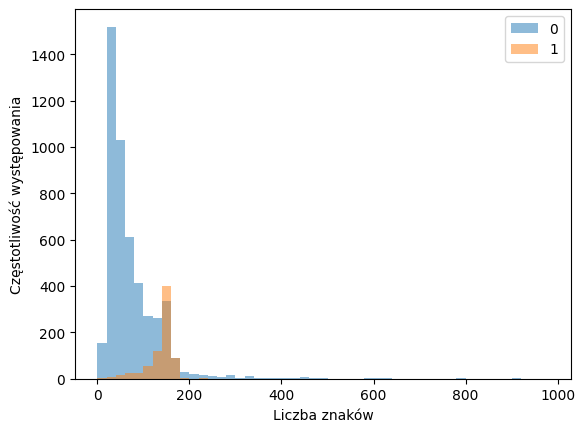

In [3]:
for cat in sms['is_spam'].unique():
    sms[sms['is_spam'] == cat]['text'].str.len().plot(bins=np.arange(0, 1000, 20), 
                                                      kind='hist', label=cat, alpha=0.5)
plt.xlabel('Liczba znaków')
plt.ylabel('Częstotliwość występowania')
# plt.yscale('log')
plt.legend();

In [4]:
X = sms['text']
y = sms['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.2, random_state=0)

vect = CountVectorizer(stop_words='english')
vect.fit(X_train)

X_train_scaled     = vect.transform(X_train)
X_test_scaled      = vect.transform(X_test)
X_train_scaled_inv = vect.inverse_transform(X_train_scaled)
X_test_scaled_inv  = vect.inverse_transform(X_test_scaled)

In [5]:
nbc = MultinomialNB()
nbc.fit(X_train_scaled, y_train)
y_train_pred = nbc.predict(X_train_scaled)
y_test_pred = nbc.predict(X_test_scaled)

Początkowo skopiowałem niezbędny kod z części głównej laboratorium

Liczba cech (słów): 7442
Sparsity macierzy: 0.9989482346072962


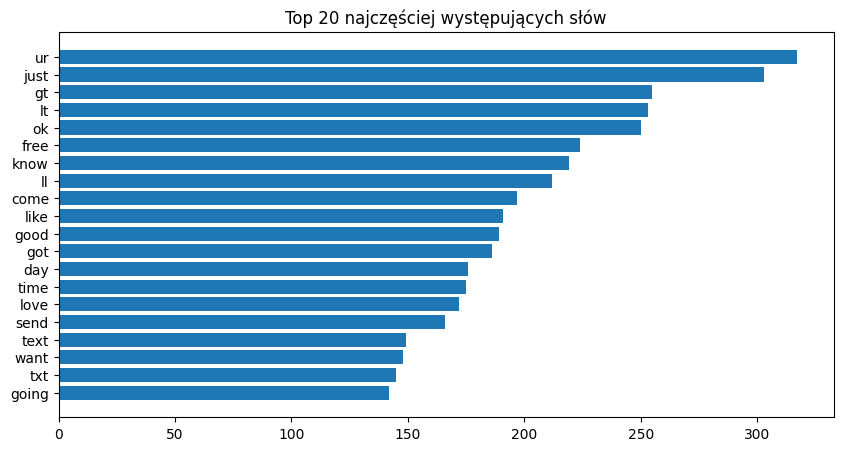

In [6]:
print("Liczba cech (słów):", X_train_scaled.shape[1])

sparsity = 1.0 - (X_train_scaled.nnz / (X_train_scaled.shape[0] * X_train_scaled.shape[1]))
print("Sparsity macierzy:", sparsity)

words = vect.get_feature_names_out()
counts = X_train_scaled.toarray().sum(axis=0)

top_idx = np.argsort(counts)[-20:]

plt.figure(figsize=(10, 5))
plt.barh([words[i] for i in top_idx], counts[top_idx])
plt.title("Top 20 najczęściej występujących słów")
plt.show()

W ramach eksploracyjnej analizy danych analizujemy macierz danych, aby zrozumieć ile słów powstało po wektoryzacji, jak bardzo macierz jest rzadka oraz które słowa najczęściej występują.

Pozwala to ocenić jakość reprezentacji modelu i wskazać potencjalne problemy. 

Po analizie mamy: 7442 słowa, czyli model działa w wysokim wymiarze. Sparsity wysokie, około 0.9989, czyli tylko około 0,1% komórek ma wartość różną od 0, a więc macierz jest bardzo rzadka. Jest to typowe dla danych tekstowych. Najczęstsze słowa są w większości bardzo ogólne, choć widzimy kilka typowych słów: (free, win, txt) - typowe dla spamu

In [7]:
results = []

param_grid = {
    "ngram_range": [(1, 1), (1, 2), (1, 3)],
    "min_df": [1, 2, 5],
    "max_df": [0.9, 0.95, 1.0]
}

for ngram in param_grid["ngram_range"]:
    for min_df in param_grid["min_df"]:
        for max_df in param_grid["max_df"]:

            vect = CountVectorizer(
                stop_words='english',
                ngram_range=ngram,
                min_df=min_df,
                max_df=max_df
            )

            X_train_vec = vect.fit_transform(X_train)
            X_test_vec = vect.transform(X_test)

            model = MultinomialNB()
            model.fit(X_train_vec, y_train)

            y_prob = model.predict_proba(X_test_vec)[:, 1]
            auc = roc_auc_score(y_test, y_prob)

            results.append((ngram, min_df, max_df, auc))

results = sorted(results, key=lambda x: x[3], reverse=True)

print("Top 10 konfiguracji:")
for r in results[:10]:
    print(r)

Top 10 konfiguracji:
((1, 1), 2, 0.9, 0.9796226048049801)
((1, 1), 2, 0.95, 0.9796226048049801)
((1, 1), 2, 1.0, 0.9796226048049801)
((1, 1), 1, 0.9, 0.9762460572206706)
((1, 1), 1, 0.95, 0.9762460572206706)
((1, 1), 1, 1.0, 0.9762460572206706)
((1, 1), 5, 0.9, 0.9729945669542985)
((1, 1), 5, 0.95, 0.9729945669542985)
((1, 1), 5, 1.0, 0.9729945669542985)
((1, 2), 2, 0.9, 0.9722859088193201)


Na podstawie EDA, testuję różne wartości:
- min_df, z powodu wysokiego sparsity, aby usunąć rzadkie słowa
- max_df, z powodu obecności ogólnych słów, aby usunąć bardzo częste
- ngramów, z racji możliwych zależności między słowami

Najlepszy wynik ROCAUC uzyskano dla ngramów (1,1), min_df = 2 oraz max_df = 0.9

In [8]:
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)
mnb_pred = mnb.predict(X_test_vec)

bnb = BernoulliNB()
bnb.fit(X_train_vec > 0, y_train)
bnb_pred = bnb.predict(X_test_vec > 0)

diff_idx = np.where(mnb_pred != bnb_pred)[0]
print("Liczba różnic:", len(diff_idx))

mnb_better = []
bnb_better = []

for i in diff_idx:
    true = y_test.iloc[i]

    if mnb_pred[i] == true and bnb_pred[i] != true:
        mnb_better.append(i)
    elif bnb_pred[i] == true and mnb_pred[i] != true:
        bnb_better.append(i)

print("MultinomialNB lepszy w:", len(mnb_better), "przypadkach")
for idx in mnb_better[:5]:
    print(X_test.iloc[idx])
    print()

print("BernoulliNB lepszy w:", len(bnb_better), "przypadkach")
for idx in bnb_better[:5]:
    print(X_test.iloc[idx])
    print()


Liczba różnic: 25
MultinomialNB lepszy w: 16 przypadkach
FreeMsg>FAV XMAS TONES!Reply REAL

You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750

Please CALL 08712402972 immediately as there is an urgent message waiting for you

Free msg. Sorry, a service you ordered from 81303 could not be delivered as you do not have sufficient credit. Please top up to receive the service.

Bloomberg -Message center +447797706009 Why wait? Apply for your future http://careers. bloomberg.com

BernoulliNB lepszy w: 9 przypadkach
Total video converter free download type this in google search:)

These won't do. Have to move on to morphine

K..i deleted my contact that why?

K k:) sms chat with me.

If you were/are free i can give. Otherwise nalla adi entey nattil kittum



Porównano dwa modele: MultinomialNB i BernoulliNB. Pierwszy z nich uwzględnia liczność słów, a drugi tylko obecność słów. Zaobserwowano, że MultinomialNB lepiej sobie radzi z dłuższymi wiadomościami, a BernoulliNB lepiej działa dla krótkich wiadomości, gdzie sama obecność słowa jest wystarczająca do określenia klasyfikacji wiadomości

In [9]:
pipe_mnb = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('clf', MultinomialNB())
])

pipe_mnb.fit(X_train, y_train)

y_prob_mnb = pipe_mnb.predict_proba(X_test)[:, 1]

print("ROC AUC (MultinomialNB + TF-IDF):", 
      roc_auc_score(y_test, y_prob_mnb))

from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()
    
pipe_gnb = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('to_dense', DenseTransformer()),
    ('clf', GaussianNB())
])

pipe_gnb.fit(X_train, y_train)

y_prob_gnb = pipe_gnb.predict_proba(X_test)[:, 1]

print("ROC AUC (GaussianNB + TF-IDF):",
      roc_auc_score(y_test, y_prob_gnb))

ROC AUC (MultinomialNB + TF-IDF): 0.9777884308085651
ROC AUC (GaussianNB + TF-IDF): 0.8550307779954702


Zaobserwowano, że GaussianNB osiąga gorsze wyniki niż MultinomialNB. Wynika to z tego, że GaussianNB zakłada, że cechy mają rozkład normalny, a dane tekstowe są rzadkie i mają rozkład daleki od normalnego. Dodatkowo cechy są w większości zerowe (wysoka sparsity), a wartości TF-IDF nie mają charakteru ciągłego w sensie rozkładu Gaussa. MultinomialNB jest lepiej dopasowany do danych tekstowych, bo modeluje częstości występowania słów.

In [10]:
pipe = Pipeline([
    ('vect', CountVectorizer(stop_words='english')),
    ('tfidf', TfidfTransformer()),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Najlepsze parametry:", grid.best_params_)
print("Najlepszy wynik ROC AUC:", grid.best_score_)

y_prob = grid.predict_proba(X_test)[:, 1]
print("ROC AUC (test):", roc_auc_score(y_test, y_prob))

Najlepsze parametry: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Najlepszy wynik ROC AUC: 0.993666902486417
ROC AUC (test): 0.9847360595828645


Wytrenowano regresję logistyczną robiąc przeszukanie po hiperparametrach. Najlepsze wyniki osiągnięto dla parametrów: C=10, penalty='l2', solver='liblinear'. Model osiągnął wysoką wartość ROC AUC. Wysoka wartość parametru C oznacza słabszą regularyzację. Regresja logistyczna osiąga bardzo dobre wyniki ze względu na liniowy charakter problemu oraz dobrą reprezentację danych przy użyciu TF-IDF.

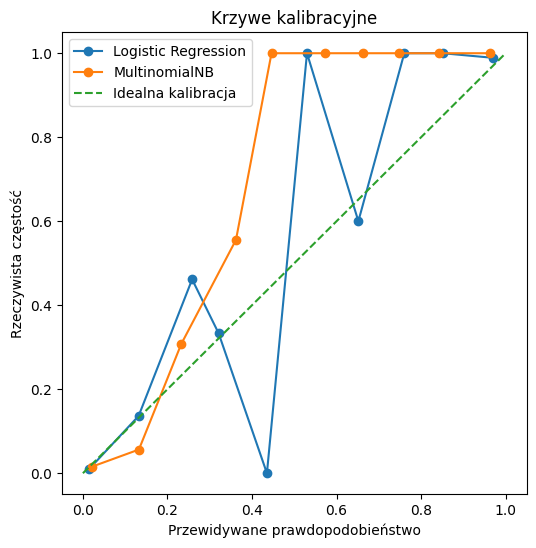

In [11]:
y_prob_lr = grid.predict_proba(X_test)[:, 1]
y_prob_nb = pipe_mnb.predict_proba(X_test)[:, 1]

prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10)
prob_true_nb, prob_pred_nb = calibration_curve(y_test, y_prob_nb, n_bins=10)

plt.figure(figsize=(6, 6))

plt.plot(prob_pred_lr, prob_true_lr, marker='o', label='Logistic Regression')
plt.plot(prob_pred_nb, prob_true_nb, marker='o', label='MultinomialNB')

plt.plot([0, 1], [0, 1], linestyle='--', label='Idealna kalibracja')

plt.xlabel('Przewidywane prawdopodobieństwo')
plt.ylabel('Rzeczywista częstość')
plt.legend()
plt.title('Krzywe kalibracyjne')
plt.show()

Porównano kalibrację modeli Logistic Regression oraz MultinomialNB. Krzywa kalibracyjna pokazuje na ile przewidywane prawdopodobieństwa odpowiadają rzeczywistym częstościom występowania klasy pozytywnej

Logistic Regression wykazuje dobrą kalibrację w początkowej fazie dla niskich prawdopodobieństw, następnie staje się dość niestabilny, wykazując duże wahania. W niektórych zakresach jest lepszy niż MultinomialNB.

MultinomialNB jest konsekwentnie nadmiernie pewny siebie. Linia znajduje się powyżej przekątnej dla większości zakresu poza samym początkiem. MultinomialNB często ma tendencję do generowania prawdopodobieństw przesuniętych w stronę ekstremów (blisko 0 lub 1)

In [12]:
vect = grid.best_estimator_.named_steps['vect']
clf = grid.best_estimator_.named_steps['clf']

feature_names = vect.get_feature_names_out()
coefs = clf.coef_[0]

top_spam_idx = np.argsort(coefs)[-20:]

top_ham_idx = np.argsort(coefs)[:20]

print("TOP SPAM n-gramy:")
print([feature_names[i] for i in top_spam_idx])

print("\nTOP HAM n-gramy:")
print([feature_names[i] for i in top_ham_idx])

TOP SPAM n-gramy:
['tones', 'video', 'urgent', '18', 'prize', 'won', 'com', 'reply', 'text', 'ringtone', 'chat', 'stop', '150p', 'mobile', 'service', '50', 'www', 'uk', 'claim', 'txt']

TOP HAM n-gramy:
['lt', 'gt', 'll', 'ok', 'home', 'liked', 'later', 'think', 'da', 'way', 'sorry', 'happy', 'come', 'pls', 'place', 'road', 'got', 'hey', 'lor', 'fullonsms']


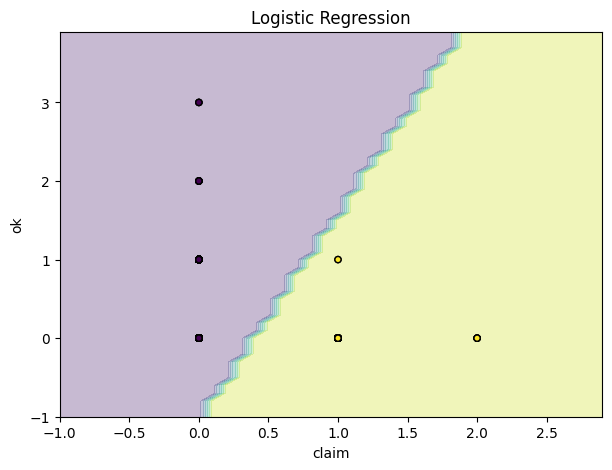

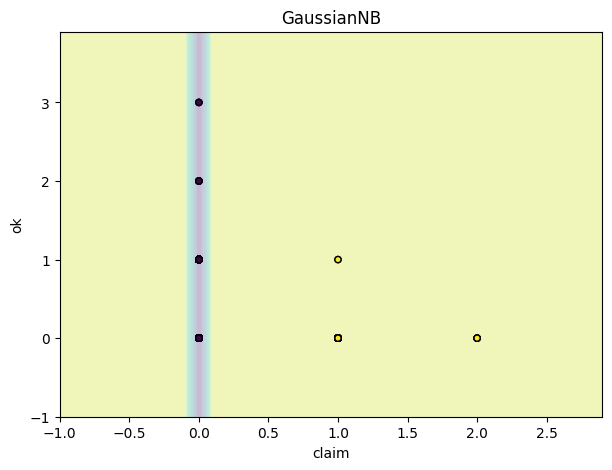

In [13]:
X_all = vect.transform(X)

feature_names = vect.get_feature_names_out()

feat1 = 'claim'
feat2 = 'ok'

i1 = list(feature_names).index(feat1)
i2 = list(feature_names).index(feat2)

X_2d = X_all[:, [i1, i2]].toarray()

lr_2d = LogisticRegression()
lr_2d.fit(X_2d, y)

gnb_2d = GaussianNB()
gnb_2d.fit(X_2d, y)

def plot_decision_boundary(model, X, y, title, feat1, feat2):
    h = 0.1

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
        X[:, 0], 
        X[:, 1], 
        c=y, 
        edgecolor='k', 
        s=20
    )

    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(title)
    plt.show()

plot_decision_boundary(lr_2d, X_2d, y, "Logistic Regression", feat1, feat2)
plot_decision_boundary(gnb_2d, X_2d, y, "GaussianNB", feat1, feat2)

Jako 2 reprezentacyjne n-gramy wybrałem "claim" silnie związany ze spamem oraz "ok" charakterystyczny dla wiadomości niespamowych. Pozwala to uzyskać czytelną separację klas w przestrzeni dwuwymiarowej.

Logistic Regression podzielił obszar na dwie części, gdzie w jednej z części znajdują się wiadomości spamowe, a w drugiej niespamowe, natomiast GaussianNB wydzielił obszar w specyficzny sposób biorąc punkty leżące na tej samej prostej. Na ogół GaussianNB tworzy bardziej zakrzywione bądź nieregularne obszary, gdzie Logistic Regression dzieli je prostą linią.

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Zaimplementuj [elastyczny naiwny klasyfikator Bayesa](https://arxiv.org/pdf/1302.4964) tj. NBC, w którym wiaygodność $p(x_i | y_k)$ jest modelowana osobno dla każdej klasy $k$ na podstawie [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation) dla wszystkich punktów treningowych ($i=1\dots n$)
2. [0-1 pkt] Porównaj wyniki uzyskane za pomocą Gaussowskiego KDE dla różnych wartości parametru wygładzania ($h$, *smoothing*, *bandwidth*) z "globalnym" klasyfikatorem z rozkładem Gaussa (patrz zadanie obowiązkowe)

In [14]:
class KDENaiveBayes(BaseEstimator, ClassifierMixin):
    def __init__(self, bandwidth=1.0):
        self.bandwidth = bandwidth

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.class_priors_ = {}
        self.kde_models_ = {}

        n_samples, n_features = X.shape

        for cls in self.classes_:
            X_cls = X[y == cls]

            self.class_priors_[cls] = len(X_cls) / len(X)

            self.kde_models_[cls] = []

            for i in range(n_features):
                kde = KernelDensity(
                    kernel='gaussian', 
                    bandwidth=self.bandwidth
                )

                kde.fit(X_cls[:, i].reshape(-1, 1))

                self.kde_models_[cls].append(kde)

        return self

    def predict_proba(self, X):
        X = np.asarray(X)

        probs = []

        for x in X:
            class_log_probs = []

            for cls in self.classes_:
                log_prob = np.log(self.class_priors_[cls])

                for i, kde in enumerate(self.kde_models_[cls]):
                    log_prob += kde.score_samples([[x[i]]])[0]

                class_log_probs.append(log_prob)

            class_log_probs = np.array(class_log_probs)
            class_probs = np.exp(class_log_probs - np.max(class_log_probs))
            class_probs /= class_probs.sum()

            probs.append(class_probs)

        return np.array(probs)
    
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

Liczba cech użytych do KDE: 100

=== KDE Naive Bayes ===
ROC AUC (KDE Naive Bayes, h=1.0): 0.938096627620993

=== GaussianNB ===
ROC AUC (GaussianNB): 0.7316235218919782

=== Test bandwidth ===
Trwa bandwidth = 0.1
Trwa bandwidth = 0.5
Trwa bandwidth = 1.0
Trwa bandwidth = 2.0

=== Wyniki KDE dla różnych h ===
bandwidth = 0.1  | ROC AUC = 0.9384
bandwidth = 0.5  | ROC AUC = 0.9374
bandwidth = 1.0  | ROC AUC = 0.9381
bandwidth = 2.0  | ROC AUC = 0.9402


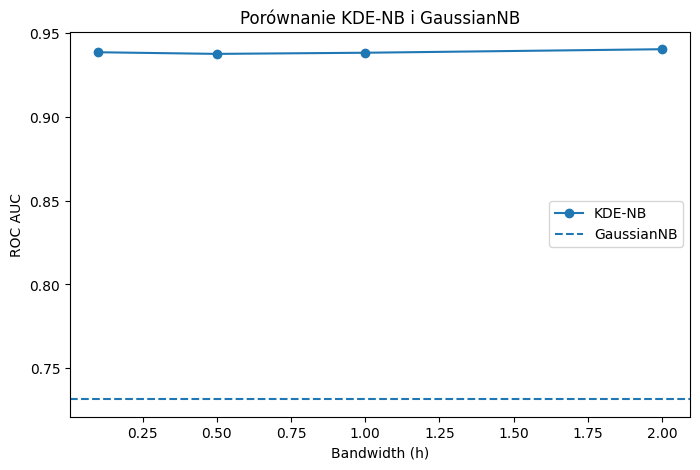

In [16]:
vect_kde = CountVectorizer(
    stop_words='english',
    max_features=100
)

X_train_kde = vect_kde.fit_transform(X_train).toarray()
X_test_kde = vect_kde.transform(X_test).toarray()

print("Liczba cech użytych do KDE:", X_train_kde.shape[1])

print("\n=== KDE Naive Bayes ===")

kde_nb = KDENaiveBayes(bandwidth=1.0)

kde_nb.fit(X_train_kde, y_train)

y_prob_kde = kde_nb.predict_proba(X_test_kde)[:, 1]

kde_auc = roc_auc_score(y_test, y_prob_kde)

print("ROC AUC (KDE Naive Bayes, h=1.0):", kde_auc)


print("\n=== GaussianNB ===")

gnb = GaussianNB()

gnb.fit(X_train_kde, y_train)

y_prob_gnb = gnb.predict_proba(X_test_kde)[:, 1]

gnb_auc = roc_auc_score(y_test, y_prob_gnb)

print("ROC AUC (GaussianNB):", gnb_auc)

print("\n=== Test bandwidth ===")

bandwidths = [0.1, 0.5, 1.0, 2.0]
results = []

for bw in bandwidths:
    print("Trwa bandwidth =", bw)

    model = KDENaiveBayes(bandwidth=bw)
    model.fit(X_train_kde, y_train)

    y_prob = model.predict_proba(X_test_kde)[:, 1]

    auc = roc_auc_score(y_test, y_prob)

    results.append((bw, auc))


print("\n=== Wyniki KDE dla różnych h ===")

for bw, auc in results:
    print(f"bandwidth = {bw:<4} | ROC AUC = {auc:.4f}")


bw_vals = [r[0] for r in results]
auc_vals = [r[1] for r in results]

plt.figure(figsize=(8,5))

plt.plot(bw_vals, auc_vals, marker='o', label='KDE-NB')
plt.axhline(
    y=gnb_auc,
    linestyle='--',
    label='GaussianNB'
)

plt.xlabel("Bandwidth (h)")
plt.ylabel("ROC AUC")
plt.title("Porównanie KDE-NB i GaussianNB")
plt.legend()

plt.show()

Zaimplementowałem Naiwny Klasyfikator Bayesa, w którym rozkład warunkowy każdej cechy dla każdej klasy jest estymowany osobno za pomocą KDE z jądrem Gaussowskim. Ograniczyłem liczbę cech do 100 najczęstszych, bo inaczej bardzo wolno się liczyło.

Elastyczny Naiwny Klasyfikator Bayesa oparty o KDE osiągnął znacznie lepsze wyniki niż klasyczny GaussianNB. Potwierdza to, że założenie globalnego rozkładu normalnego jest zbyt restrykcyjne dla danych tekstowych, których cechy mają niestandardowe i silnie niesymetryczne rozkłady. KDE umożliwia bardziej elastyczne modelowanie rozkładów warunkowych, co znacząco poprawia jakość klasyfikacji. Wpływ parametru bandwidth był umiarkowany. Najlepszy wynik dla bandwidth równego 2, co sugeruje korzystny efekt umiarkowanego wygładzenia.